# Customer Segmentation: A Key to Unlocking Business Growth and Success 
**Authors**: Pedro Ambar, Inês Chainho  
**Date**: April 2026

This notebook walks through the full pipeline for segmenting a retail store’s customer base. The goal is to enable more targeted marketing strategies by understanding customer behavior.

### Project Steps:
1. Data Loading and EDA  
2. Preprocessing and Feature Engineering  
3. Exploratory Data Analysis  
4. Clustering and Segmentation  
5. Cluster Profiling  
6. Market Basket Analysis  
7. Exporting Results

## 1. Environment Setup and Initial EDA

We begin by importing all necessary libraries and explore and analyze our data.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from Preprocessing import preprocess_customer_info, fill_missing_values, plot_correlation_heatmap
from EDA import plot_feature_histograms, print_highly_correlated_pairs, plot_feature_barplots
from Clustering import find_optimal_k, plot_kmeans_scores, plot_pca_k_grid, kmeans_model
from Cluster_Visualization import plot_pca_2d, plot_cluster_boxplots, plot_cluster_discrete_means

In [2]:
# Load customer_info dataset
c_info = pd.read_csv("customer_info.csv")
c_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   customer_name                            33038 non-null  str    
 2   customer_gender                          33038 non-null  str    
 3   customer_birthdate                       32873 non-null  str    
 4   kids_home                                32708 non-null  float64
 5   teens_home                               32708 non-null  float64
 6   number_complaints                        32377 non-null  float64
 7   distinct_stores_visited                  32708 non-null  float64
 8   lifetime_spend_groceries                 33038 non-null  float64
 9   lifetime_spend_electronics               32377 non-null  float64
 10  typical_hour                             32377 non-null  

In [3]:
# Initial inspection of customer_info
display(c_info.head(15))
display(c_info.describe().T)

,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,...,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,...,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,...,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,...,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,...,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,...,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188
5,9,Msc. Nadine Garcia,female,10/09/1968 04:01 AM,1.0,1.0,1.0,6.0,16530.0,1156.0,...,76.0,513.0,225.0,NaN,84.0,0.150646,2011.0,1.0,38.735577,-9.172423
6,10,Phd. Franklin Alba,male,06/09/1971 05:08 AM,2.0,1.0,0.0,1.0,22240.0,NaN,...,1723.0,886.0,203.0,119.0,202.0,0.275412,2014.0,1.0,38.730322,-9.144022
7,11,Bsc. Robert Hansing,male,07/19/1977 10:22 AM,1.0,1.0,1.0,6.0,29765.0,1543.0,...,731.0,1240.0,1849.0,397.0,180.0,0.164251,2017.0,1.0,38.739328,-9.225047
8,12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,...,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756
9,14,Msc. Arron Burgener,male,11/28/1948 07:53 PM,1.0,0.0,1.0,3.0,7981.0,2151.0,...,24.0,1393.0,178.0,90.0,57.0,0.197353,2017.0,1.0,38.788819,-9.184158


,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,19951.500000,29964.750000,40000.000000
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000


In [4]:
# Inspect categorical variables
categorical_cols = ["customer_name", "customer_gender", "customer_birthdate"]
display(c_info[categorical_cols].describe())

,customer_name,customer_gender,customer_birthdate
count,33038,33038,32873
unique,32543,2,32852
top,Susan Smith,female,11/03/1998 06:10 PM
freq,5,16577,2


In [5]:
# Summary of categorical variables
print("Gender distribution:")
display(c_info["customer_gender"].value_counts(dropna=False))

print("Number of unique customer names:", c_info["customer_name"].nunique())
print("Number of unique birthdates:", c_info["customer_birthdate"].nunique())

Gender distribution:


customer_gender
female    16577
male      16461
Name: count, dtype: int64

Number of unique customer names: 32543
Number of unique birthdates: 32852


In [6]:
for col in c_info.columns:
    print(f"{col}: {c_info[col].nunique()} unique values")

customer_id: 33038 unique values
customer_name: 32543 unique values
customer_gender: 2 unique values
customer_birthdate: 32852 unique values
kids_home: 9 unique values
teens_home: 7 unique values
number_complaints: 8 unique values
distinct_stores_visited: 10 unique values
lifetime_spend_groceries: 20792 unique values
lifetime_spend_electronics: 8549 unique values
typical_hour: 18 unique values
lifetime_spend_vegetables: 2539 unique values
lifetime_spend_nonalcohol_drinks: 1432 unique values
lifetime_spend_alcohol_drinks: 2390 unique values
lifetime_spend_meat: 2237 unique values
lifetime_spend_fish: 2196 unique values
lifetime_spend_hygiene: 2754 unique values
lifetime_spend_videogames: 2085 unique values
lifetime_spend_petfood: 950 unique values
lifetime_total_distinct_products: 557 unique values
percentage_of_products_bought_promotion: 31502 unique values
year_first_transaction: 36 unique values
loyalty_card_number: 1 unique values
latitude: 33038 unique values
longitude: 33038 uniqu

<Axes: >

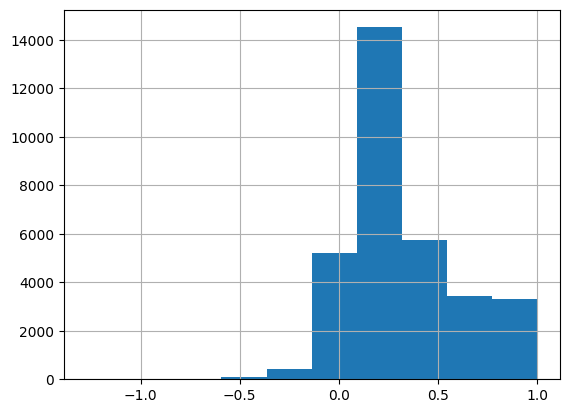

In [7]:
# Inspect var percentage_of_products_bought_promotion
c_info['percentage_of_products_bought_promotion'].hist()

In [8]:
# Load customer_basket dataset
customer_basket = pd.read_csv("customer_basket.csv")

customer_basket.info()
display(customer_basket.head())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   invoice_id     100000 non-null  int64
 1   list_of_goods  100000 non-null  str  
 2   customer_id    100000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 14.7 MB


,invoice_id,list_of_goods,customer_id
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807


In [9]:
# Check dataset dimensions
print("Customer info shape:", c_info.shape)
print("Customer basket shape:", customer_basket.shape)

Customer info shape: (33038, 25)
Customer basket shape: (100000, 3)


In [10]:
# Check missing values
print("Missing values in customer_info:")
display(c_info.isnull().sum())

print("Missing values in customer_basket:")
display(customer_basket.isnull().sum())

Missing values in customer_info:


customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

Missing values in customer_basket:


invoice_id       0
list_of_goods    0
customer_id      0
dtype: int64

In [11]:
# Check duplicated rows
print("Duplicated rows in customer_info:", c_info.duplicated().sum())
print("Duplicated rows in customer_basket:", customer_basket.duplicated().sum())

print("Total duplicated rows:", c_info["customer_id"].duplicated().sum())

Duplicated rows in customer_info: 0
Duplicated rows in customer_basket: 0
Total duplicated rows: 0


In [12]:
# Check connection between customer_info and customer_basket
basket_customers = set(customer_basket["customer_id"])
info_customers = set(c_info["customer_id"])

customers_only_in_basket = basket_customers - info_customers
customers_only_in_info = info_customers - basket_customers

print("Customers in basket but not in customer_info:", len(customers_only_in_basket))
print("Customers in customer_info but not in basket:", len(customers_only_in_info))

Customers in basket but not in customer_info: 0
Customers in customer_info but not in basket: 4911


## 2. Preprocessing and Feature Engineering

We clean and transform the data:
- Extract degree from the var customer_name and convert to an ordinal var
- Transform var customer_gender into a binary var
- Extract age from var costumer_birthdate
- Extract tenure from var year_first_transaction and handle incorrect values
- Tranform var loyalty_card_number
- Handle incorrect values in vars percentage_of_products_bought_promotion
- Remove irrelevant columns
- Handle missing values

In [13]:
clean_df = preprocess_customer_info(c_info)

clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33038 entries, 0 to 33037
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_id                              33038 non-null  int64  
 1   kids_home                                32708 non-null  float64
 2   teens_home                               32708 non-null  float64
 3   number_complaints                        32377 non-null  float64
 4   distinct_stores_visited                  32708 non-null  float64
 5   lifetime_spend_groceries                 33038 non-null  float64
 6   lifetime_spend_electronics               32377 non-null  float64
 7   lifetime_spend_vegetables                32377 non-null  float64
 8   lifetime_spend_nonalcohol_drinks         33038 non-null  float64
 9   lifetime_spend_alcohol_drinks            32708 non-null  float64
 10  lifetime_spend_meat                      32377 non-null  

In [14]:
clean_df = fill_missing_values(clean_df)
missing_after_preprocessing = clean_df.isnull().sum()
display(missing_after_preprocessing[missing_after_preprocessing > 0])
clean_df.head(5)

Series([], dtype: int64)

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,percentage_of_products_bought_promotion,latitude,longitude,degree_num,is_female,age,tenure,has_loyalty_card,typical_hour_sin,typical_hour_cos
0,3,1.0,1.0,1.0,3.0,11731.0,4553.0,373.0,323.0,177.0,...,0.631599,38.794428,-9.215739,1,1,56.295688,6.0,1,1.224647e-16,-5.000000e-01
1,4,1.0,0.0,0.0,2.0,13694.0,963.0,2012.0,533.0,95.0,...,0.149890,38.751711,-9.179611,1,1,50.546201,13.0,1,1.224647e-16,-5.000000e-01
2,5,0.0,0.0,1.0,2.0,12407.0,0.0,555.0,101.0,118.0,...,0.069126,38.780678,-9.160656,2,0,54.721424,21.0,0,2.588190e-01,-9.659258e-01
3,7,0.0,0.0,2.0,1.0,7493.0,1105.0,84.0,757.0,1133.0,...,0.253609,38.739548,-9.148679,0,0,43.603012,5.0,1,-1.000000e+00,-1.836970e-16
4,8,0.0,0.0,3.0,1.0,9187.0,10841.0,380.0,592.0,718.0,...,0.186569,38.733071,-9.188188,0,0,56.821355,5.0,1,-9.659258e-01,-2.588190e-01


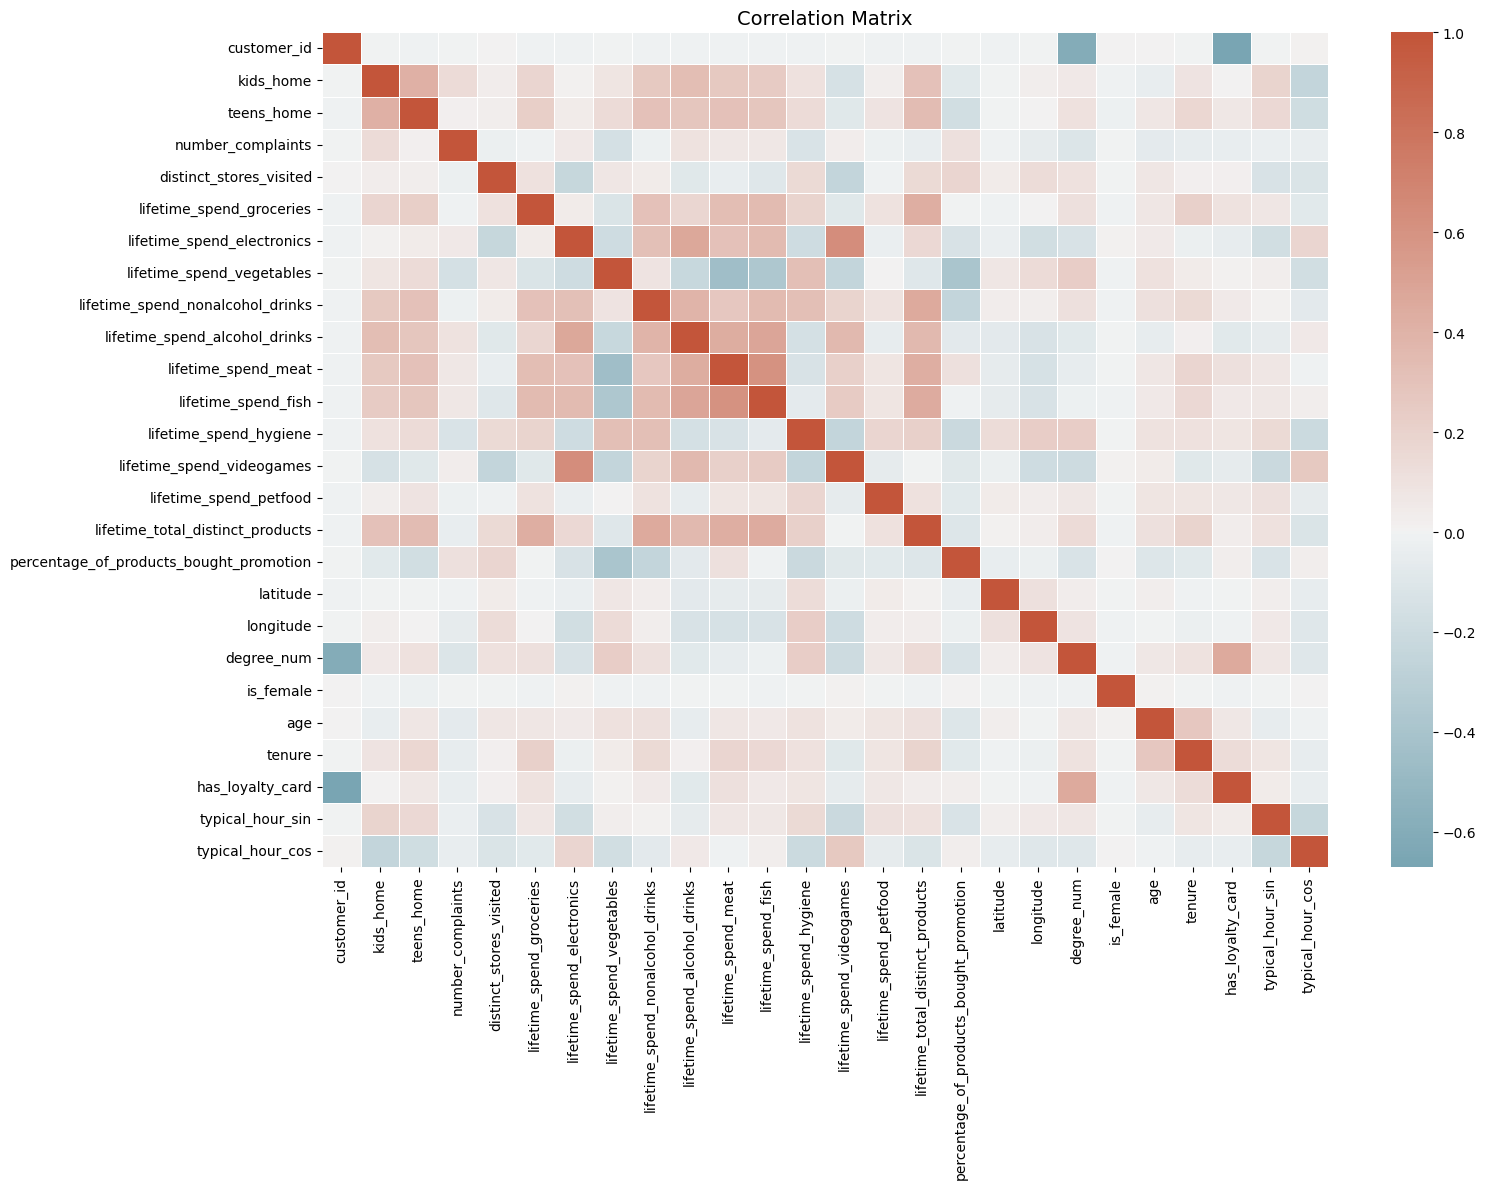

In [15]:
plot_correlation_heatmap(clean_df)

In [16]:
print("Original customer_info rows:", c_info.shape[0])
print("Clean dataframe rows:", clean_df.shape[0])

print("Unique customer_id in original data:", c_info["customer_id"].nunique())
print("Unique customer_id in clean data:", clean_df["customer_id"].nunique())

print("Total missing values after preprocessing:", clean_df.isnull().sum().sum())
print("Negative customer tenure values:", (clean_df["tenure"] < 0).sum())
print("Negative percentage_of_products_bought_promotion values:", (clean_df["percentage_of_products_bought_promotion"] < 0).sum())

print("Clean dataframe shape:", clean_df.shape)

Original customer_info rows: 33038
Clean dataframe rows: 33038
Unique customer_id in original data: 33038
Unique customer_id in clean data: 33038
Total missing values after preprocessing: 0
Negative customer tenure values: 0
Negative percentage_of_products_bought_promotion values: 0
Clean dataframe shape: (33038, 26)


## 3. Data Preparation for Modelling

In this section, we explore the cleaned customer dataset to understand the main patterns to properly prepare the data before applying clustering. The analysis focuses on variable distributions, outliers and correlations between variables.

In [17]:
# Exploring Multicollinearity:
print_highly_correlated_pairs(clean_df.select_dtypes(include=[np.number]), threshold=0.7)

Empty DataFrame
Columns: [var1, var2, corr]
Index: []


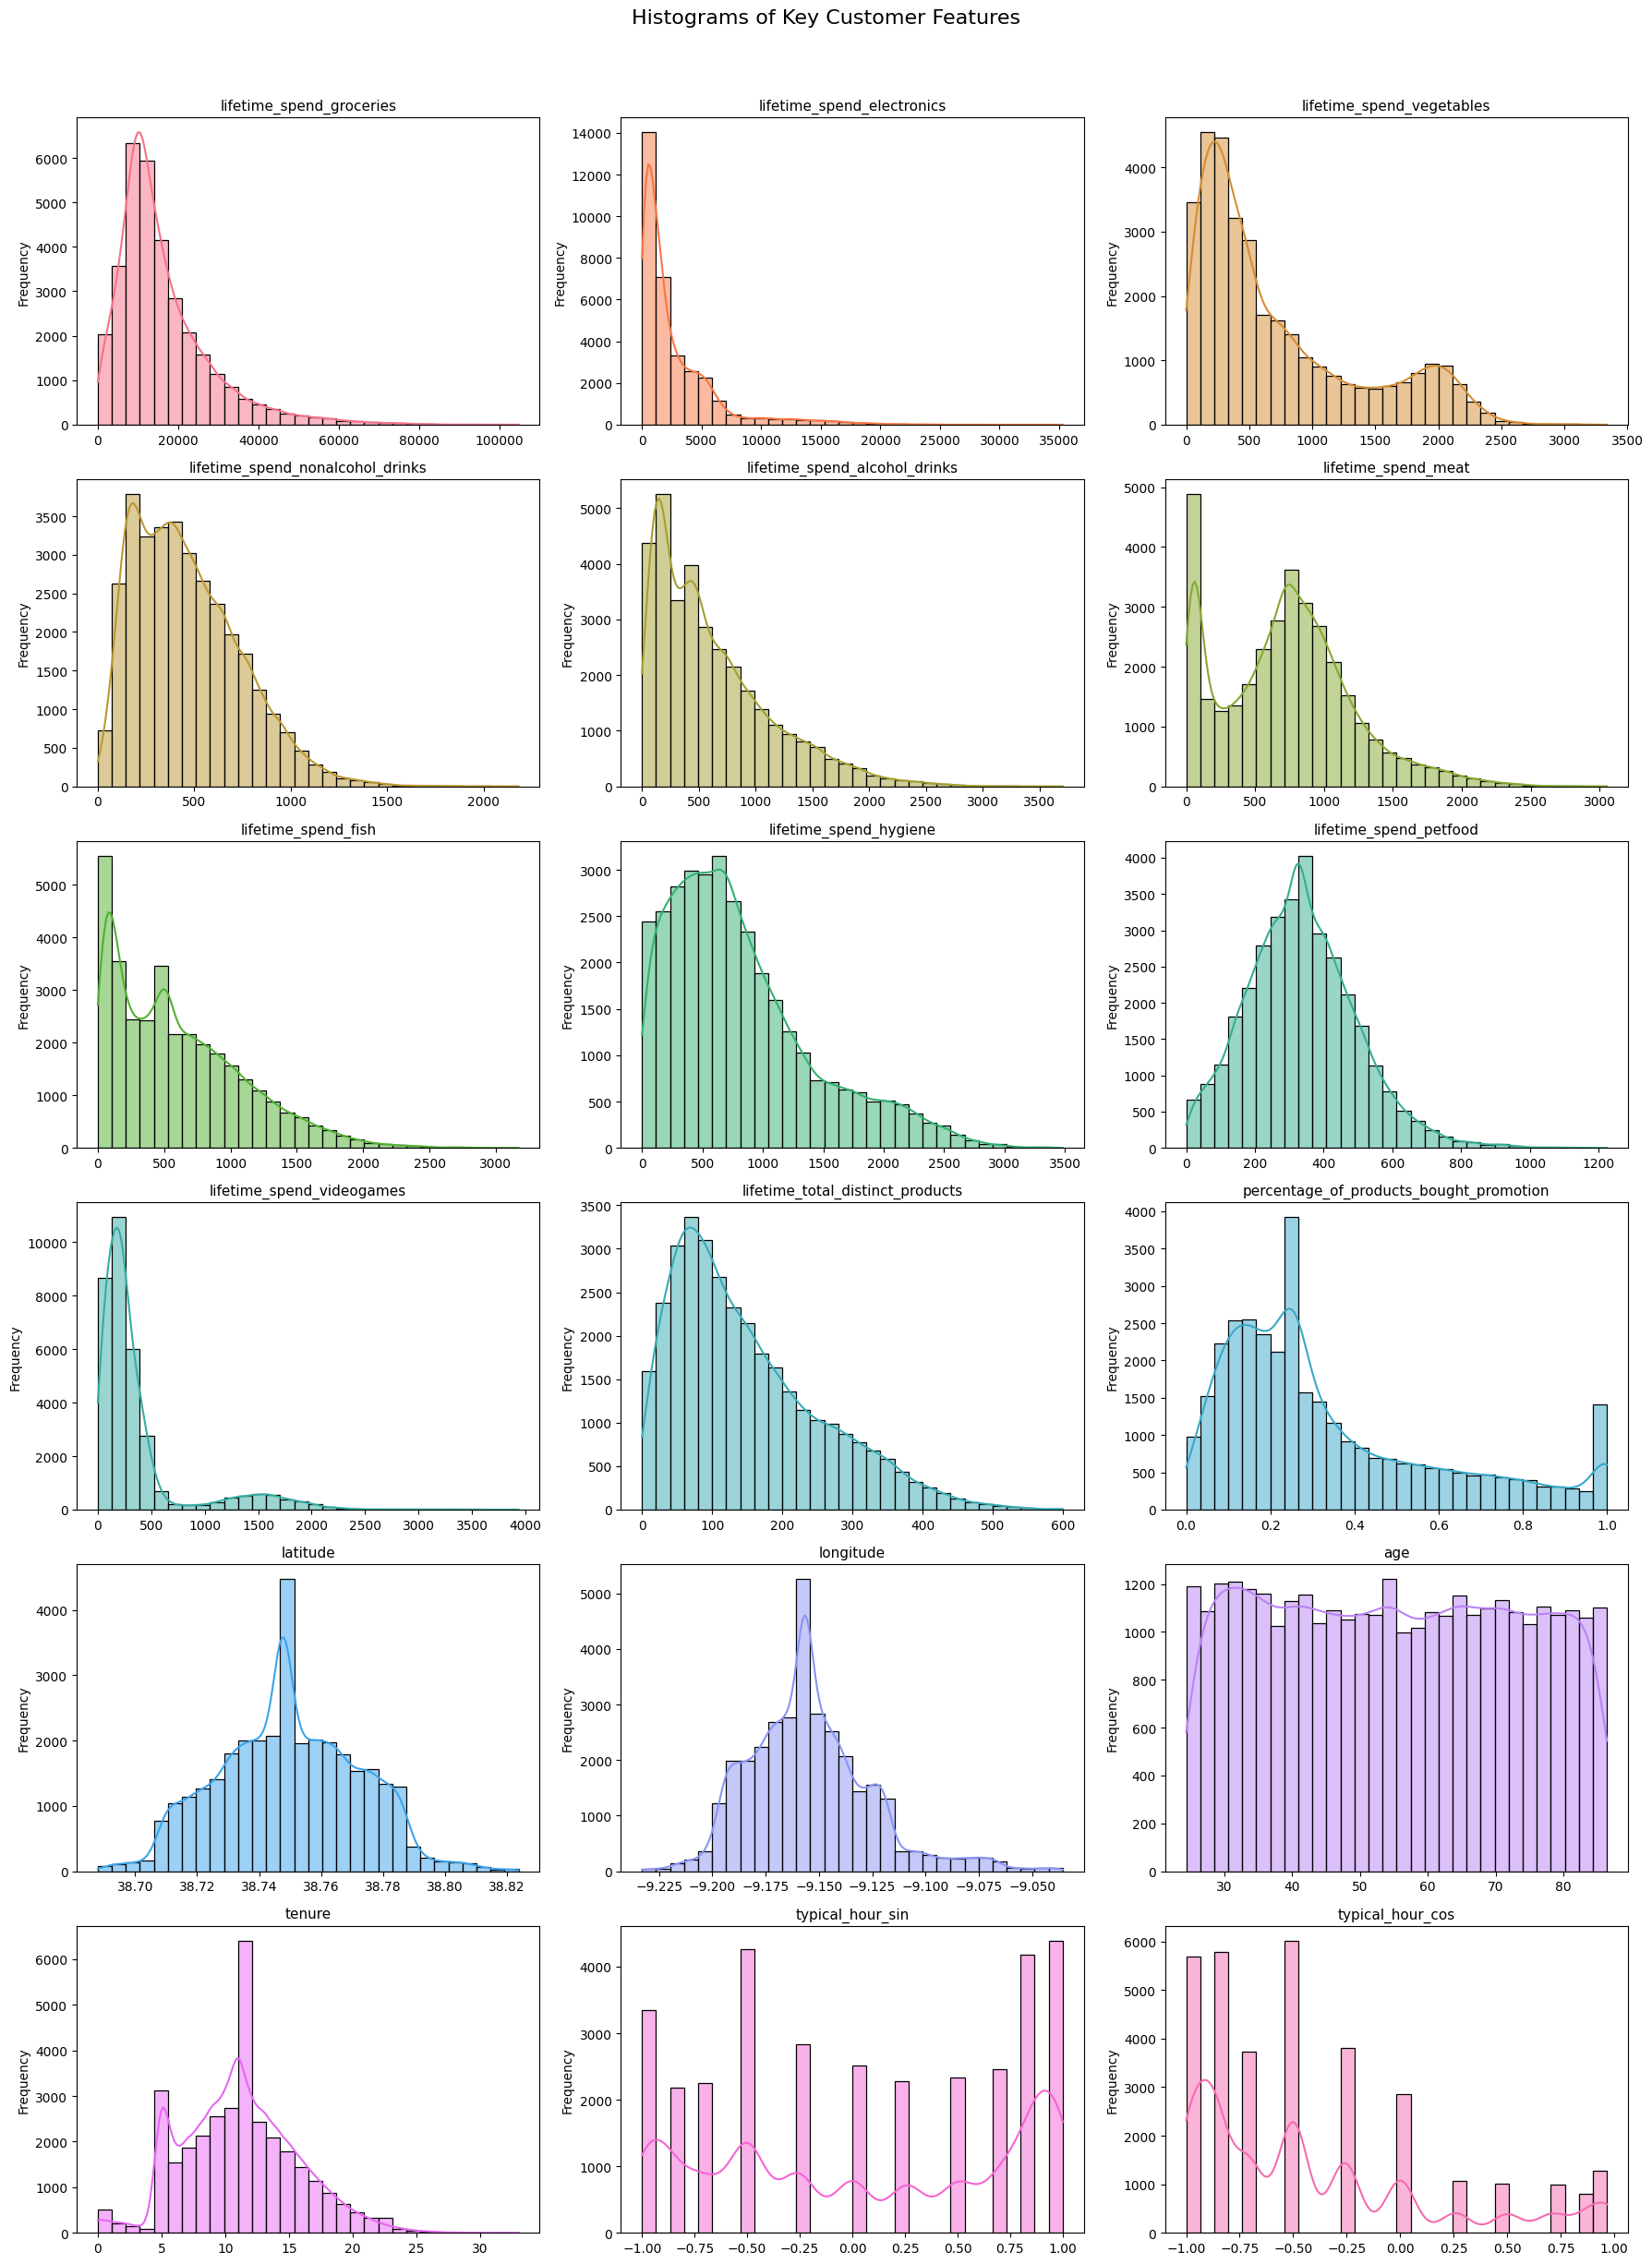

In [18]:
cont_cols = ["lifetime_spend_groceries", "lifetime_spend_electronics", "lifetime_spend_vegetables", "lifetime_spend_nonalcohol_drinks", "lifetime_spend_alcohol_drinks",
             "lifetime_spend_meat", "lifetime_spend_fish", "lifetime_spend_hygiene", "lifetime_spend_petfood", "lifetime_spend_videogames", "lifetime_total_distinct_products",
             "percentage_of_products_bought_promotion", "latitude", "longitude", "age", "tenure", "typical_hour_sin", "typical_hour_cos"]
plot_feature_histograms(clean_df, cont_cols)

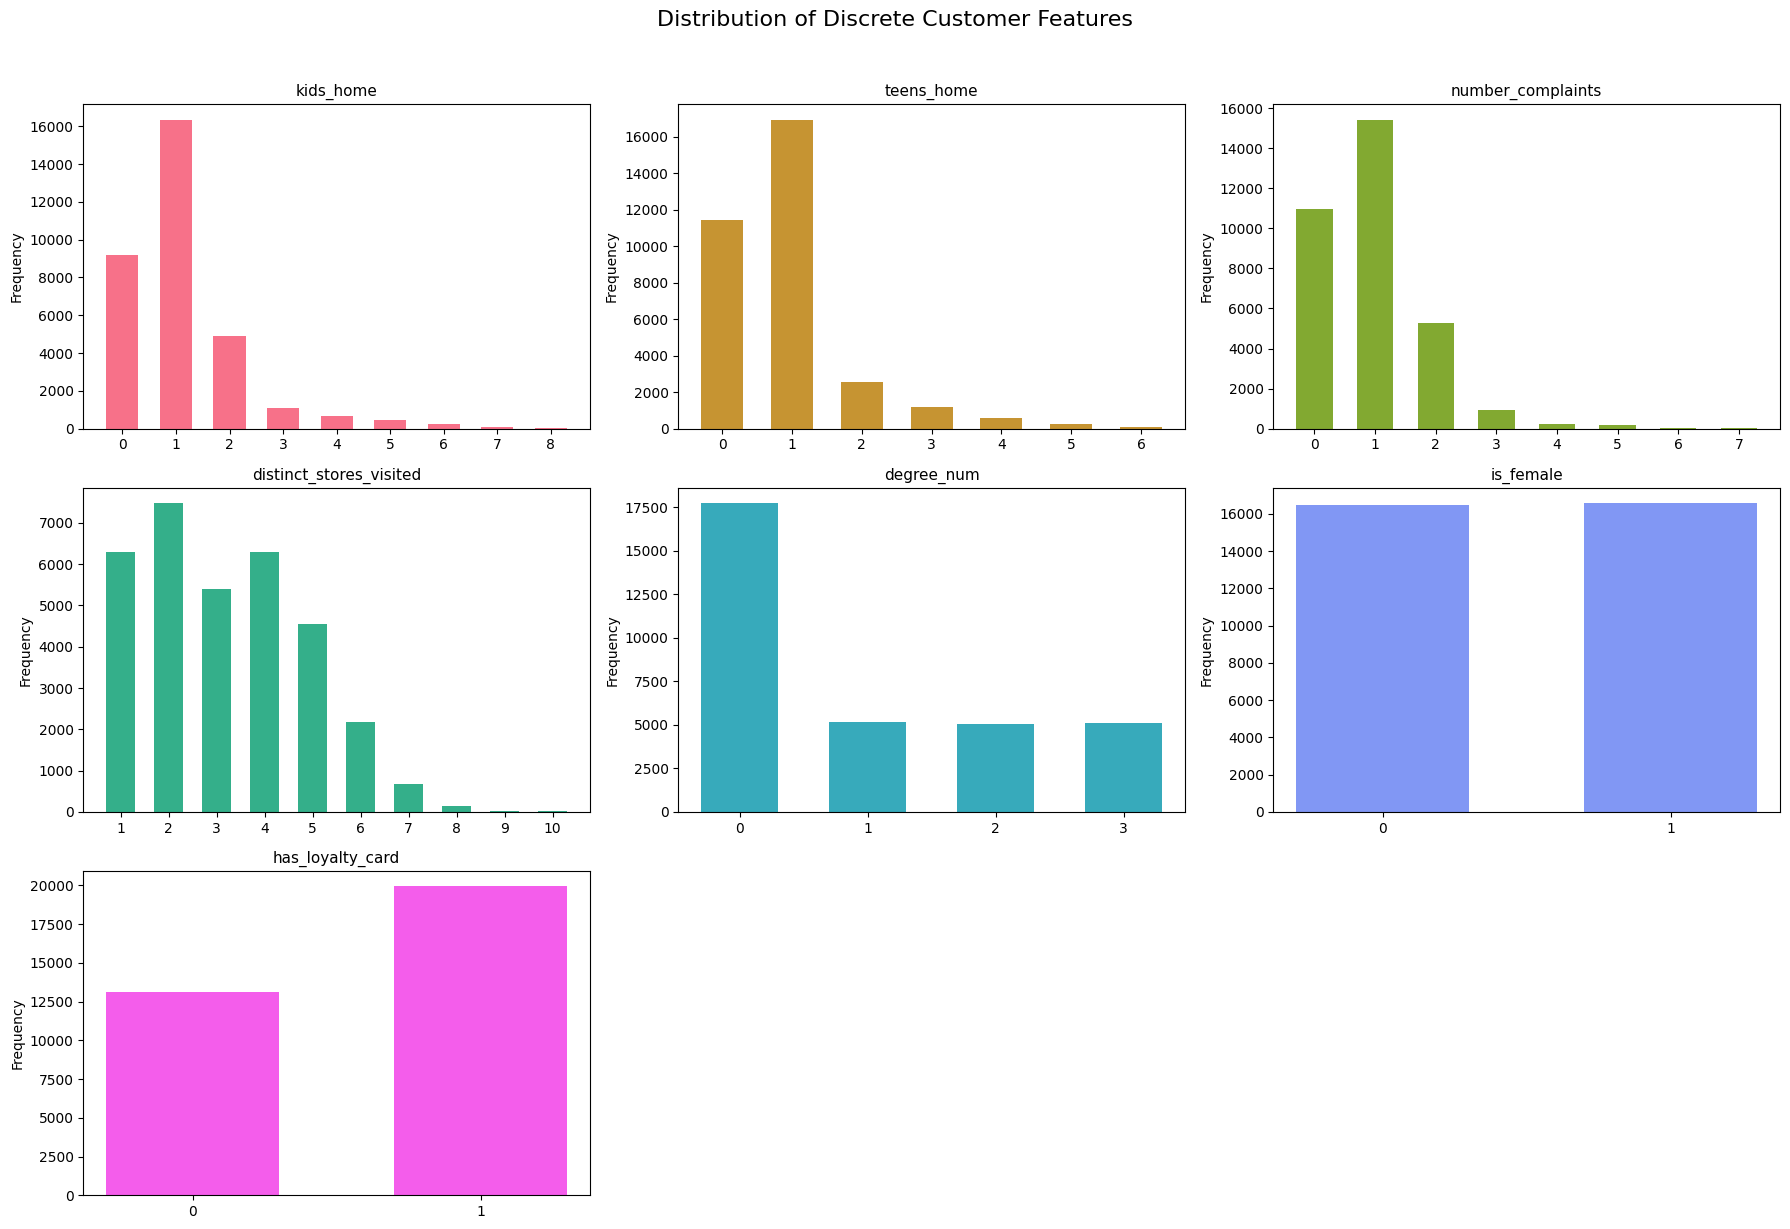

In [19]:
disc_cols = ["kids_home", "teens_home", "number_complaints", "distinct_stores_visited", "degree_num", "is_female", "has_loyalty_card"]
plot_feature_barplots(clean_df, disc_cols)

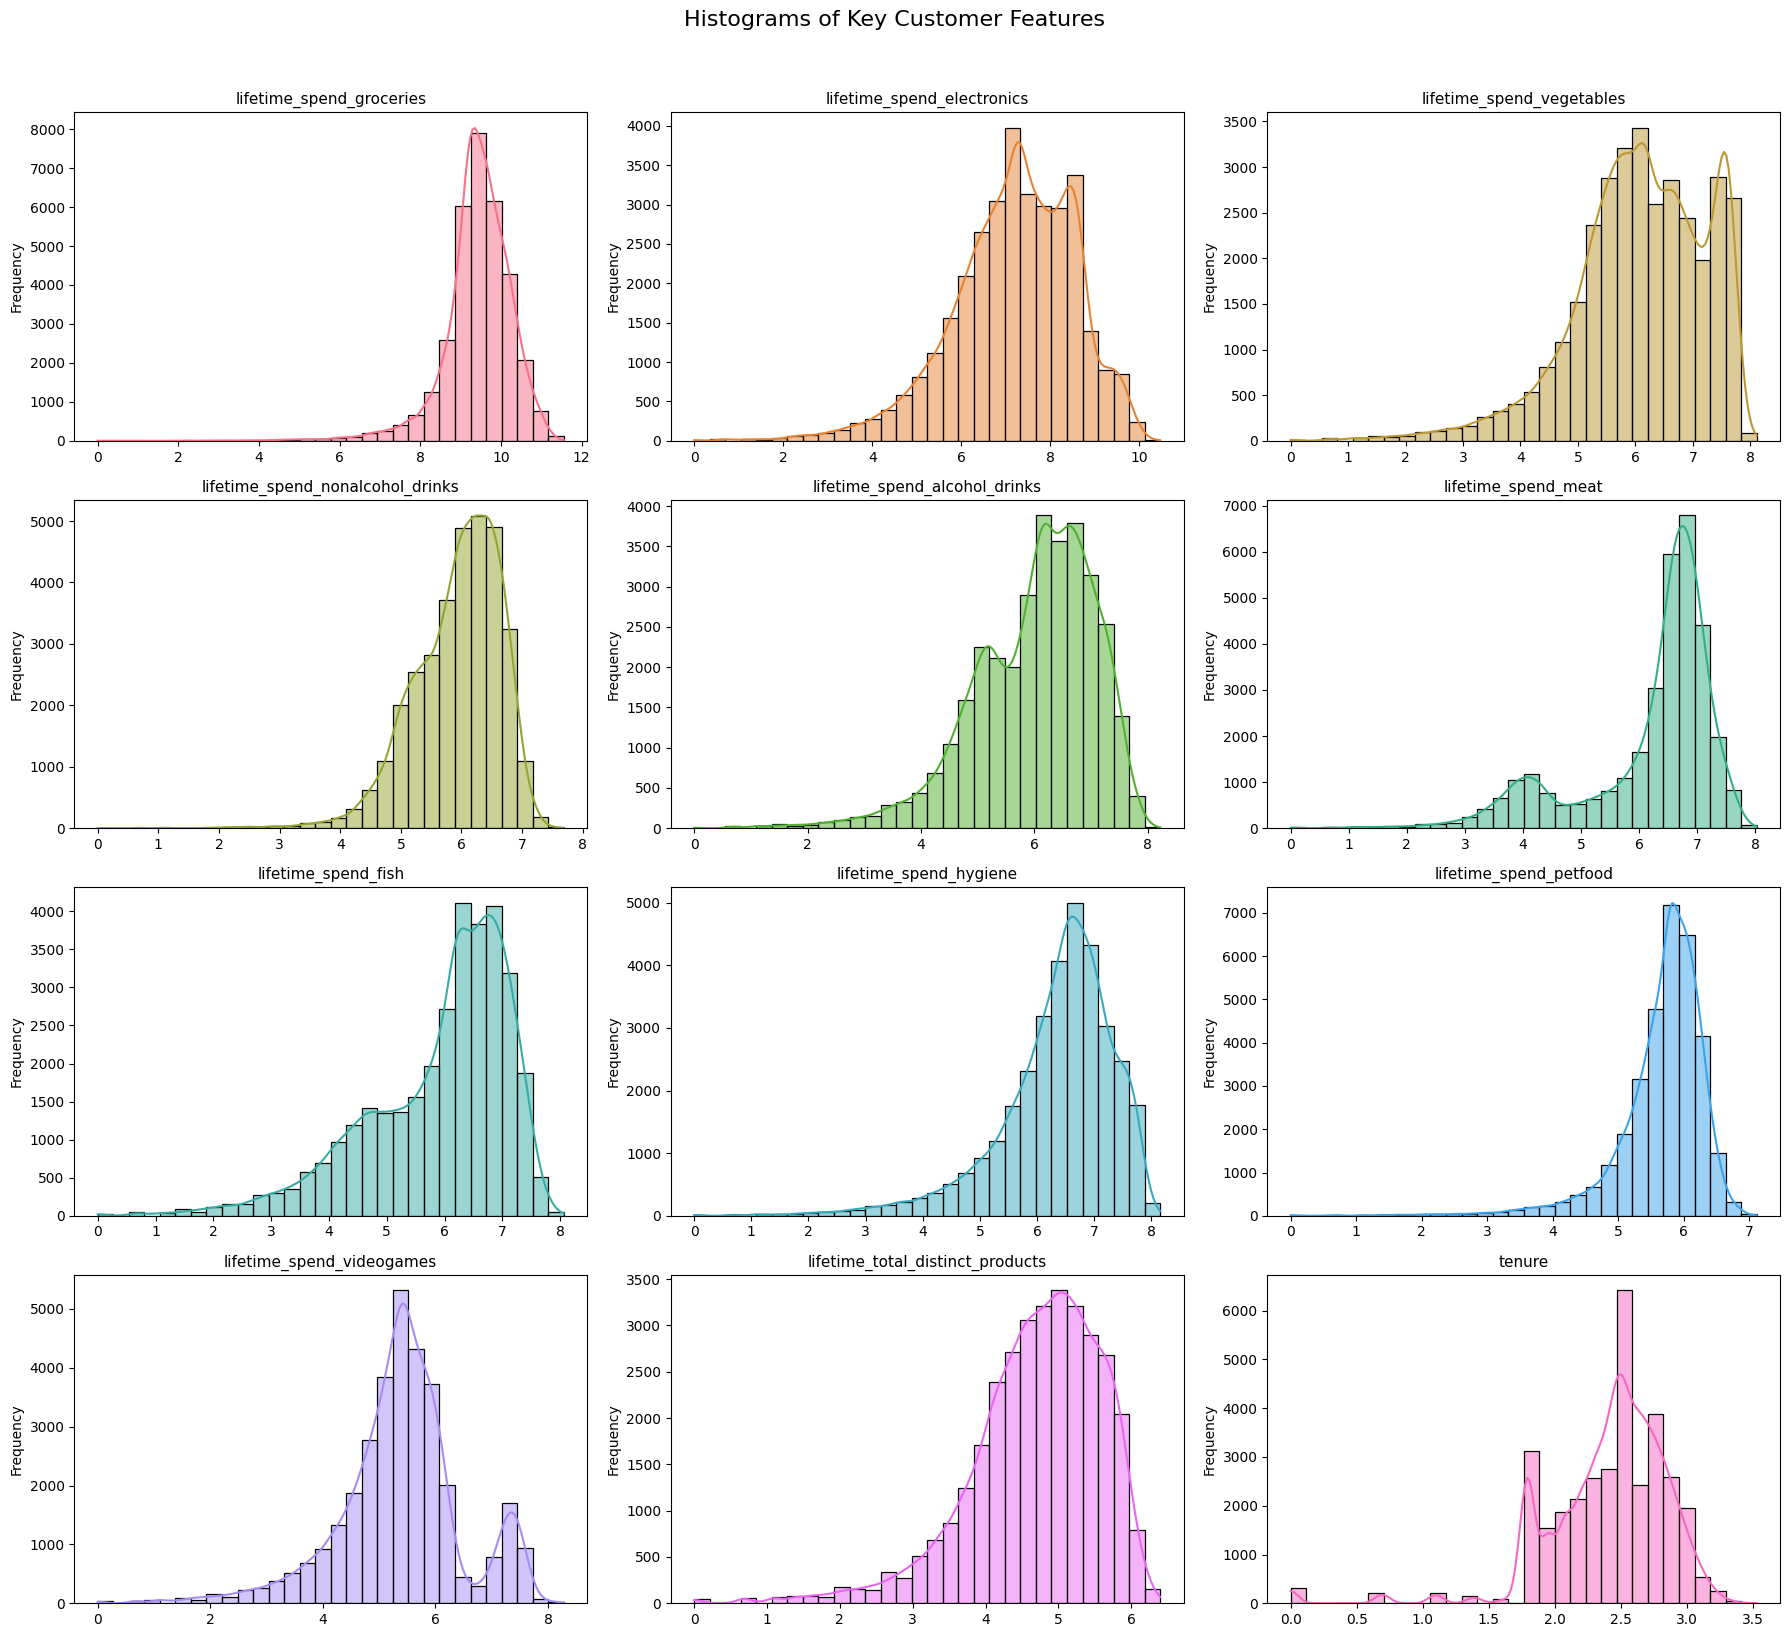

In [20]:
# skewed cols, continuous, not between 0 and 1:
skewed_cols = ["lifetime_spend_groceries", "lifetime_spend_electronics", "lifetime_spend_vegetables", "lifetime_spend_nonalcohol_drinks", "lifetime_spend_alcohol_drinks",
               "lifetime_spend_meat", "lifetime_spend_fish", "lifetime_spend_hygiene", "lifetime_spend_petfood", "lifetime_spend_videogames",
               "lifetime_total_distinct_products", "tenure"]
for col in skewed_cols:
    clean_df[col] = np.log1p(clean_df[col])

plot_feature_histograms(clean_df, skewed_cols)

In [21]:
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,33038.0,19974.265785,11538.538632,3.000000,9985.250000,1.995150e+04,29964.750000,40000.000000
kids_home,33038.0,1.114959,1.144485,0.000000,0.000000,1.000000e+00,1.000000,8.000000
teens_home,33038.0,0.899903,0.958155,0.000000,0.000000,1.000000e+00,1.000000,6.000000
number_complaints,33038.0,0.932230,0.885716,0.000000,0.000000,1.000000e+00,1.000000,7.000000
distinct_stores_visited,33038.0,3.166263,1.665815,1.000000,2.000000,3.000000e+00,4.000000,10.000000
lifetime_spend_groceries,33038.0,9.421708,0.850911,0.000000,9.065083,9.472974e+00,9.943093,11.558577
lifetime_spend_electronics,33038.0,7.184570,1.378683,0.000000,6.385194,7.293698e+00,8.209308,10.471638
lifetime_spend_vegetables,33038.0,6.085094,1.150169,0.000000,5.434811,6.156979e+00,6.960348,8.113127
lifetime_spend_nonalcohol_drinks,33038.0,5.929918,0.725163,0.000000,5.488938,6.045005e+00,6.463029,7.687539
lifetime_spend_alcohol_drinks,33038.0,6.001372,1.077904,0.000000,5.318120,6.182085e+00,6.787845,8.217439


In [22]:
customer_ids = clean_df["customer_id"]
features = clean_df.drop(columns=["customer_id"])
robust_scaler = RobustScaler()
robust_features = robust_scaler.fit_transform(features)
robust_features = pd.DataFrame(robust_features, columns=features.columns)
robust_features.describe().T

,count,mean,std,min,25%,50%,75%,max
kids_home,33038.0,0.114959,1.144485,-1.000000,-1.000000,0.000000e+00,0.000000,7.000000
teens_home,33038.0,-0.100097,0.958155,-1.000000,-1.000000,0.000000e+00,0.000000,5.000000
number_complaints,33038.0,-0.067770,0.885716,-1.000000,-1.000000,0.000000e+00,0.000000,6.000000
distinct_stores_visited,33038.0,0.083132,0.832908,-1.000000,-0.500000,0.000000e+00,0.500000,3.500000
lifetime_spend_groceries,33038.0,-0.058389,0.969137,-10.789148,-0.464563,1.011581e-15,0.535437,2.375377
lifetime_spend_electronics,33038.0,-0.059825,0.755810,-3.998488,-0.498052,0.000000e+00,0.501948,1.742183
lifetime_spend_vegetables,33038.0,-0.047121,0.753944,-4.035944,-0.473386,0.000000e+00,0.526614,1.282269
lifetime_spend_nonalcohol_drinks,33038.0,-0.118148,0.744451,-6.205787,-0.570858,0.000000e+00,0.429142,1.686221
lifetime_spend_alcohol_drinks,33038.0,-0.122957,0.733405,-4.206287,-0.587841,0.000000e+00,0.412159,1.384853
lifetime_spend_meat,33038.0,-0.409057,1.134156,-6.358931,-0.692614,0.000000e+00,0.307386,1.380028


## 4. Clustering

The optimal number of clusters is chosen using the Silhouette Score and the Inertia Score.
 - PCA for dimensionality reduction;
 - Choosing k;
 - KMeans model.

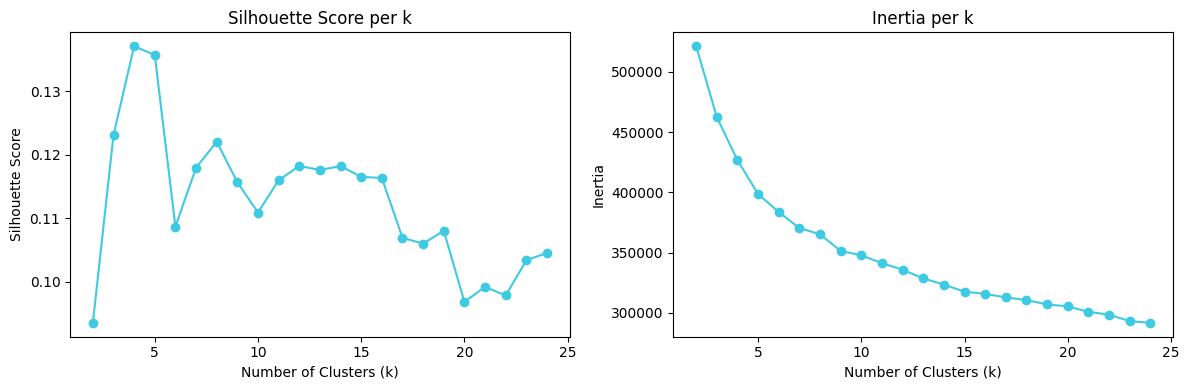

In [23]:
k_range_rb, silhouette_scores_rb, inertia_scores_rb = find_optimal_k(robust_features, k_min = 2, k_max = 25)
plot_kmeans_scores(k_range_rb, silhouette_scores_rb, inertia_scores_rb)

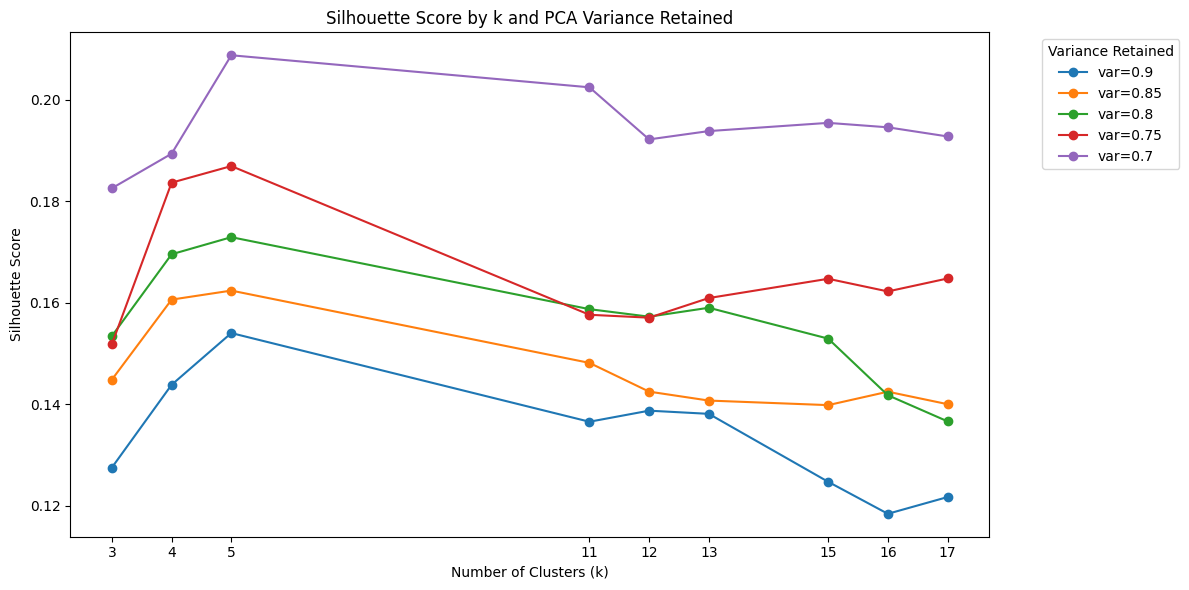

In [24]:
plot_pca_k_grid(robust_features, variance_range = [0.90, 0.85, 0.80, 0.75, 0.70], k_range = [3, 4, 5, 11, 12, 13, 15, 16, 17])

In [25]:
labels = kmeans_model(k = 5, robust_features = robust_features, var = 0.8)
clean_df["cluster"] = labels
clean_df.head(5)

,customer_id,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,latitude,longitude,degree_num,is_female,age,tenure,has_loyalty_card,typical_hour_sin,typical_hour_cos,cluster
0,3,1.0,1.0,1.0,3.0,9.370075,8.423761,5.924256,5.780744,5.181784,...,38.794428,-9.215739,1,1,56.295688,1.945910,1,1.224647e-16,-5.000000e-01,4
1,4,1.0,0.0,0.0,2.0,9.524786,6.871091,7.607381,6.280396,4.564348,...,38.751711,-9.179611,1,1,50.546201,2.639057,1,1.224647e-16,-5.000000e-01,4
2,5,0.0,0.0,1.0,2.0,9.426097,0.000000,6.320768,4.624973,4.779123,...,38.780678,-9.160656,2,0,54.721424,3.091042,0,2.588190e-01,-9.659258e-01,0
3,7,0.0,0.0,2.0,1.0,8.921858,7.008505,4.442651,6.630683,7.033506,...,38.739548,-9.148679,0,0,43.603012,1.791759,1,-1.000000e+00,-1.836970e-16,1
4,8,0.0,0.0,3.0,1.0,9.125654,9.291183,5.942799,6.385194,6.577861,...,38.733071,-9.188188,0,0,56.821355,1.791759,1,-9.659258e-01,-2.588190e-01,1


In [26]:
clean_df["typical_hour_decoded"] = (np.round(np.arctan2(clean_df["typical_hour_sin"], clean_df["typical_hour_cos"]) * 24 / (2 * np.pi)) % 24).astype(int)
clean_df.drop(columns=["typical_hour_sin", "typical_hour_cos"], inplace = True)

## 5. Cluster Profiling

To interpret the clusters, we visualize key features across segments using:
- PCA projection for 2D visualization
- Boxplots for continuous variables per cluster
- Plots with mean of discrete variables per cluster

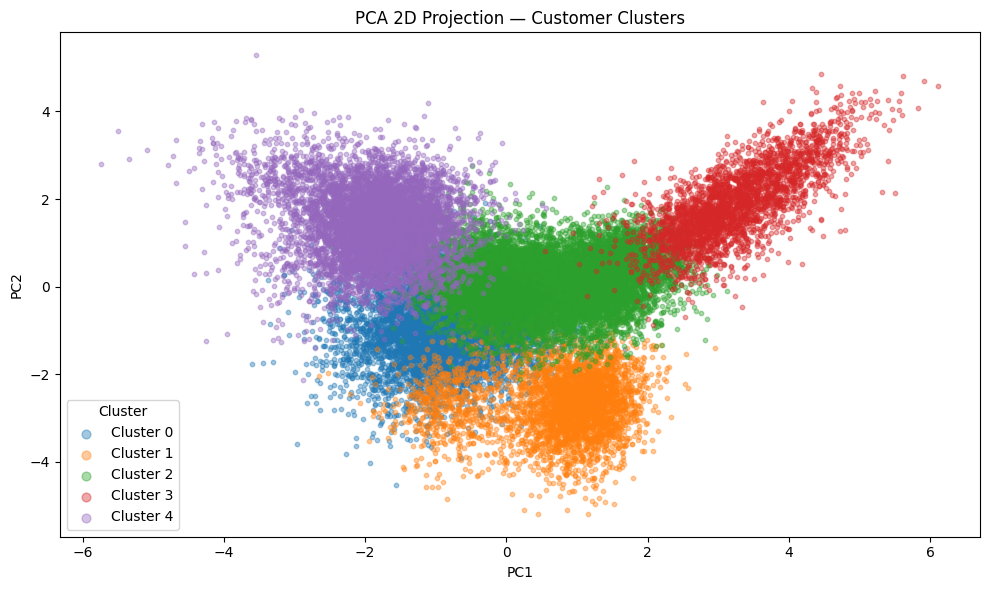

In [27]:
plot_pca_2d(robust_features, labels)

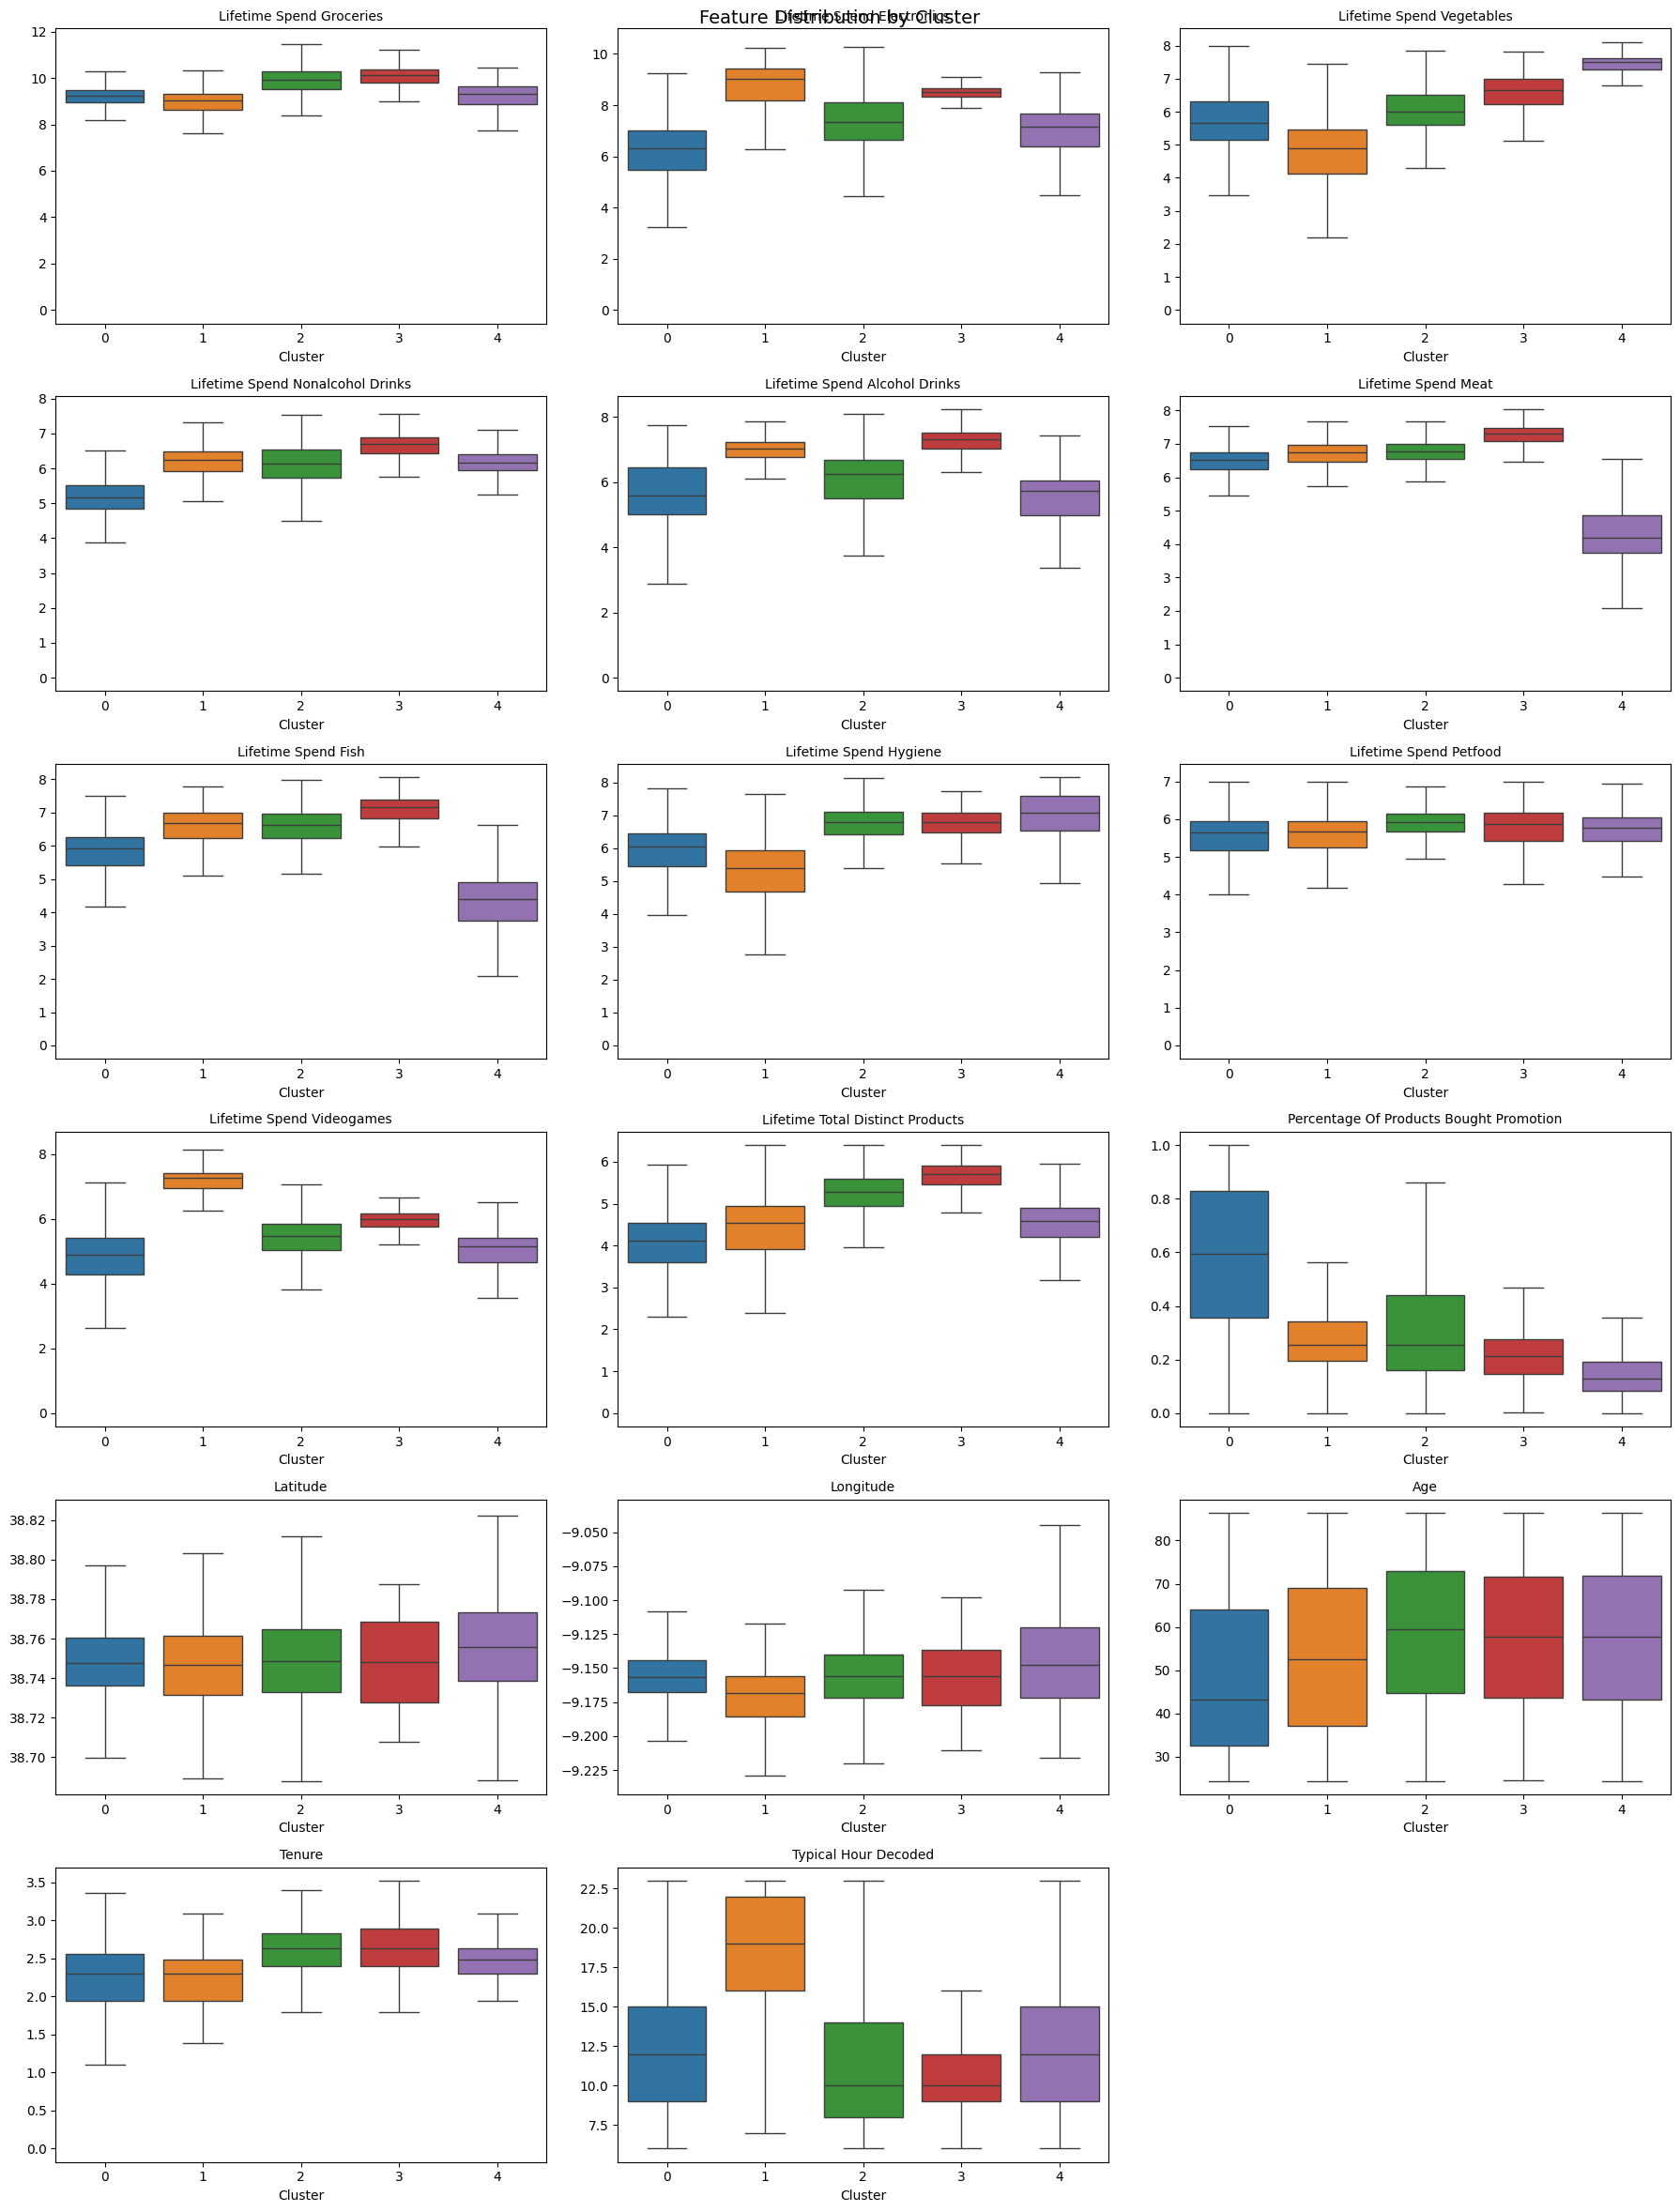

In [28]:
cont_cols.remove("typical_hour_sin")
cont_cols.remove("typical_hour_cos")
cont_cols.append("typical_hour_decoded")
plot_cluster_boxplots(clean_df, clean_df["cluster"], cont_cols)

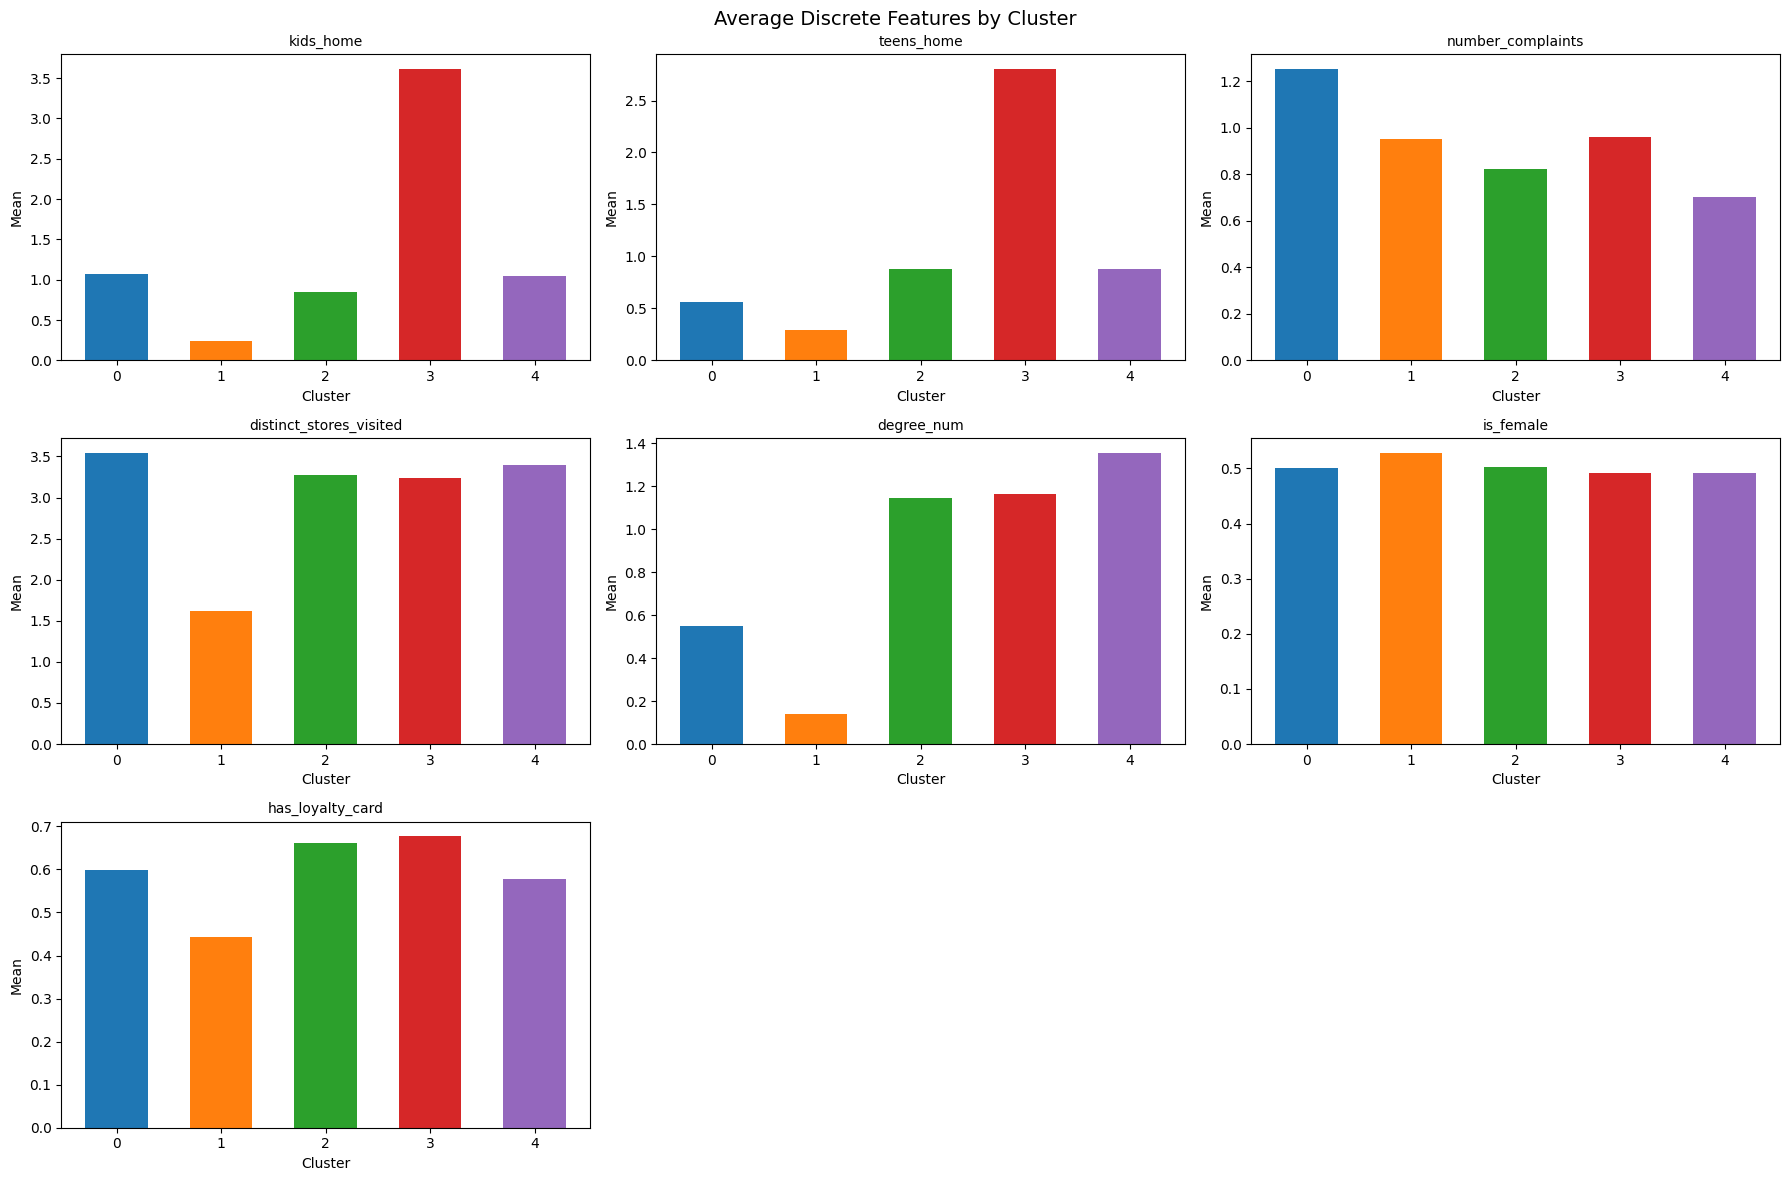

In [29]:
plot_cluster_discrete_means(clean_df, labels, disc_cols)

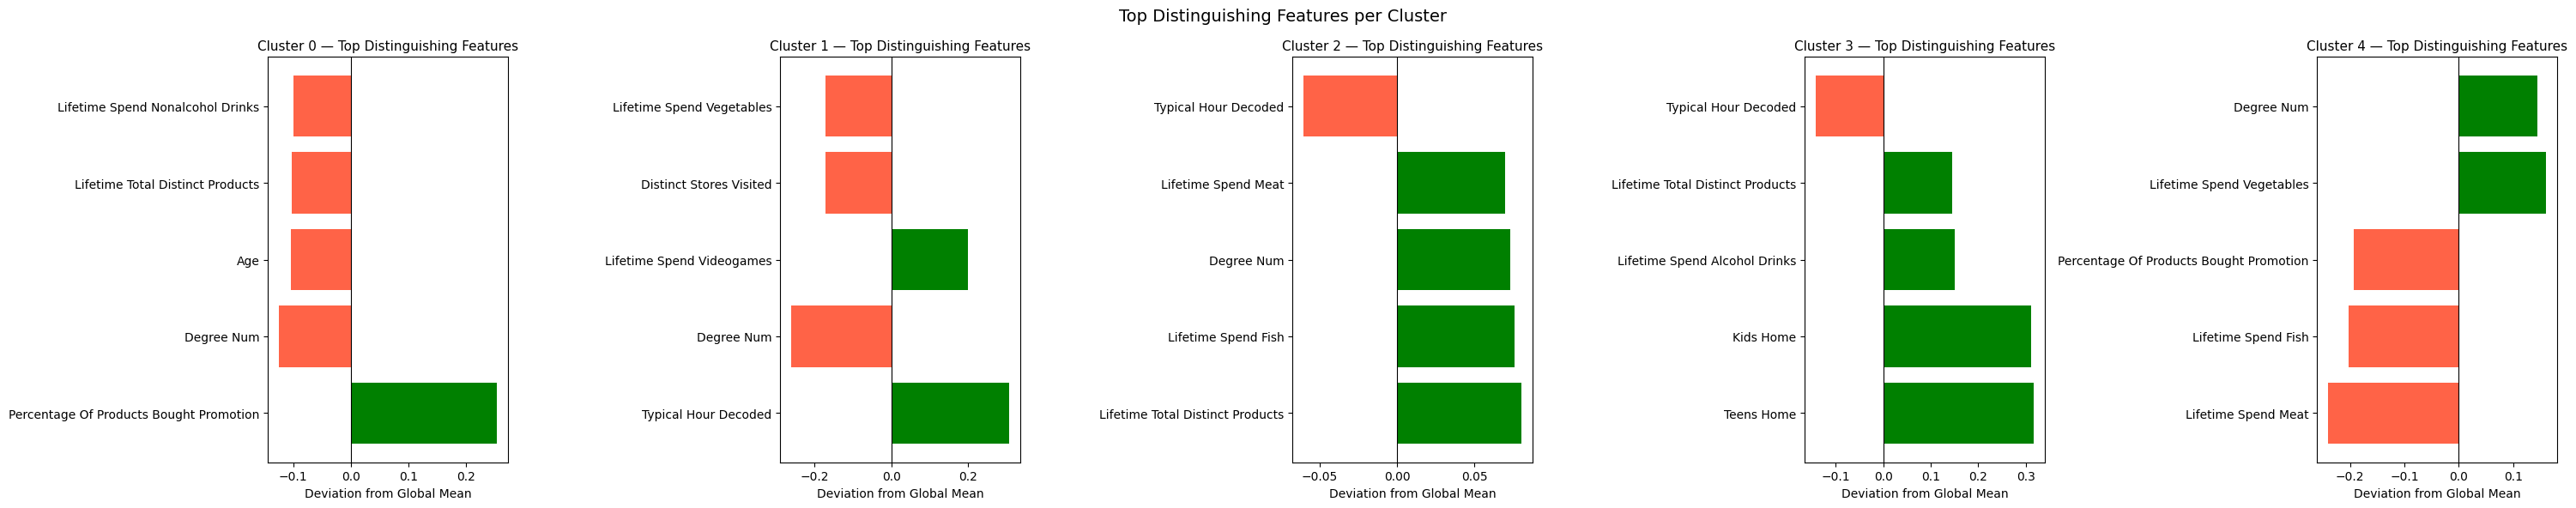

In [30]:
def plot_cluster_top_features(df, labels, top_n=5):
    colors = list(plt.cm.tab10.colors)
    
    df_plot = df.copy()
    df_plot["cluster"] = labels
    
    # normalize features to make them comparable
    from sklearn.preprocessing import MinMaxScaler
    numeric_cols = df_plot.select_dtypes(include="number").columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "cluster"]
    
    scaler = MinMaxScaler()
    df_normalized = df_plot.copy()
    df_normalized[numeric_cols] = scaler.fit_transform(df_plot[numeric_cols])
    
    cluster_means = df_normalized.groupby("cluster")[numeric_cols].mean()
    global_mean = df_normalized[numeric_cols].mean()
    
    # difference from global mean — positive means above average for this cluster
    cluster_diff = cluster_means - global_mean
    
    n_clusters = df_plot["cluster"].nunique()
    fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 6))
    
    for cluster_id in sorted(df_plot["cluster"].unique()):
        ax = axes[cluster_id]
        top_features = cluster_diff.loc[cluster_id].abs().nlargest(top_n).index
        values = cluster_diff.loc[cluster_id][top_features]
        bar_colors = ["green" if v > 0 else "tomato" for v in values]
        
        ax.barh(
            [f.replace("_", " ").title() for f in top_features],
            values,
            color=bar_colors
        )
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"Cluster {cluster_id} — Top Distinguishing Features", fontsize=11)
        ax.set_xlabel("Deviation from Global Mean")
    
    plt.suptitle("Top Distinguishing Features per Cluster", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_cluster_top_features(clean_df, labels, top_n=5)

## 6. Market Basket Analysis

We perform Market Basket Analysis using the Apriori algorithm.  
This identifies frequent itemsets and association rules from customer purchases.  
By merging basket data with the customer clusters, we can tailor insights to each segment.

In [31]:
# Load cluster assignments and basket
clustered_cust_basket = customer_basket.merge(clean_df[["customer_id", "cluster"]], on = "customer_id", how = "inner")
clustered_cust_basket.head()

,invoice_id,list_of_goods,customer_id,cluster
0,3700630,"['chicken', 'rice', 'pepper', 'whole wheat ric...",12912,2
1,10242376,"['low fat yogurt', 'tomatoes', 'pepper', 'aspa...",22853,0
2,91550,"['cake', 'tomatoes', 'pancakes', 'iPad', 'fina...",19,2
3,3137503,"['cereals', 'megaman zero', 'final fantasy XIX...",10995,3
4,7165061,"['rice', 'frozen smoothie', 'black tea', 'tea'...",27807,3
